# Módulo 07 - Tarefa 02

#### 1) Carregue a base e garanta que a base está como deveria.

Considere a base que você ajustou na lição passada. Carregue-a. Caso ainda haja alguma pendência, ajuste - lembre-se de que o scikitlearn não recebe variáveis em formato string, somente numéricas, e não aceita '*missings*'. 

- Separe 70% da base para treinamento e 30% para validação. Cada uma dessas partes terá dois objetos, um armazenando a variável resposta ```mau```e outro armazenando as variáveis explicativas (lembrando: sem variáveis string, já com as dummies).

# Importando a base de Dados

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

In [2]:
df = pd.read_csv(r'C:\Users\Theo\OneDrive\Estudo\Jupyter\Base de Dados\demo01.csv')


sexo                      object
posse_de_veiculo          object
posse_de_imovel           object
qtd_filhos                 int64
tipo_renda                object
educacao                  object
estado_civil              object
tipo_residencia           object
idade                    float64
tempo_emprego            float64
possui_celular             int64
possui_fone_comercial      int64
possui_fone                int64
possui_email               int64
qt_pessoas_residencia    float64
mau                         bool
dtype: object

# Verificando a natureza dos Dados

In [ ]:
df.dtypes # Checamos as colunas que não estão apropriadas para a árvore de decisão.

In [3]:
df.select_dtypes('object') # Verificamos as colunas nas quais usaremos dummies, funções de substituição e transformação em int.

,sexo,posse_de_veiculo,posse_de_imovel,tipo_renda,educacao,estado_civil,tipo_residencia
0,M,Y,Y,Working,Secondary / secondary special,Married,House / apartment
1,F,N,Y,Commercial associate,Secondary / secondary special,Single / not married,House / apartment
2,F,N,Y,Commercial associate,Secondary / secondary special,Single / not married,House / apartment
3,M,Y,Y,Working,Higher education,Married,House / apartment
4,F,Y,N,Working,Incomplete higher,Married,House / apartment
...,...,...,...,...,...,...,...
16645,F,N,Y,Working,Secondary / secondary special,Civil marriage,House / apartment
16646,F,N,Y,Commercial associate,Secondary / secondary special,Married,House / apartment
16647,M,Y,Y,Working,Secondary / secondary special,Married,House / apartment
16648,M,Y,Y,Working,Secondary / secondary special,Married,House / apartment


# Tratando os Dados

In [7]:
df.mau = df.mau.astype(int) # Como verificado, a coluna 'mau' estava como booleano, portanto a colocamos como 0 e 1.
for col in df.select_dtypes('object').columns:
    if 'M' in df[col].unique() or 'Y' in df[col].unique():
        df[col]=df[col].replace({'M':1, 'F':0, 'Y':1, 'N':0}) # Transformando as binária para 0 e 1.

df=pd.get_dummies(df, columns=df.select_dtypes('object').columns, drop_first=False, dtype=int) # Criando dummies para as categóricas para que sejam 0 e 1.
df.dtypes # Verifica-se de que tudo está no formato apropriado para seguir.

((16650, 33), (6770, 33))

In [23]:
df.isna().any() # Verifica se há dado ausente
df.drop_duplicates(inplace=True) # Remove os dados duplicados
df

,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,idade,tempo_emprego,possui_celular,possui_fone_comercial,possui_fone,possui_email,...,estado_civil_Married,estado_civil_Separated,estado_civil_Single / not married,estado_civil_Widow,tipo_residencia_Co-op apartment,tipo_residencia_House / apartment,tipo_residencia_Municipal apartment,tipo_residencia_Office apartment,tipo_residencia_Rented apartment,tipo_residencia_With parents
0,1,1,1,0,58.832877,3.106849,1,0,0,0,...,1,0,0,0,0,1,0,0,0,0
1,0,0,1,0,52.356164,8.358904,1,0,1,1,...,0,0,1,0,0,1,0,0,0,0
3,1,1,1,0,46.224658,2.106849,1,1,1,1,...,1,0,0,0,0,1,0,0,0,0
4,0,1,0,0,29.230137,3.021918,1,0,0,0,...,1,0,0,0,0,1,0,0,0,0
6,0,0,1,0,27.482192,4.024658,1,0,1,0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16644,0,0,1,1,34.857534,3.101370,1,1,1,0,...,0,0,1,0,0,1,0,0,0,0
16645,0,0,1,0,54.109589,9.884932,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
16646,0,0,1,0,43.389041,7.380822,1,1,1,0,...,1,0,0,0,0,1,0,0,0,0
16647,1,1,1,0,30.005479,9.800000,1,1,0,0,...,1,0,0,0,0,1,0,0,0,0


# Separando os Dados para Treino e Teste

In [29]:
y = df.mau # Isolamos a Target
X = df.drop('mau', axis=1) # Separamos as explicativas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100) # Dividindo treino e teste para explicativas e Target


#### 2) Vamos para o modelo:

1. Defina um objeto com a função da árvore de decisão vista em aula.
2. Treine o modelo com os dados que você separou para treinamento.
3. Visualize a árvore. Talvez você queira aumentar um pouco a figura.
4. Produza uma visualização da matriz de classificação (ou matriz de confusão) - coloque os rótulos como "aprovados" e "reprovados" - pois afinal de contas, são essas as decisões que se podem tomar com propostas de crédito.
5. Calcule a acurácia na base de treinamento

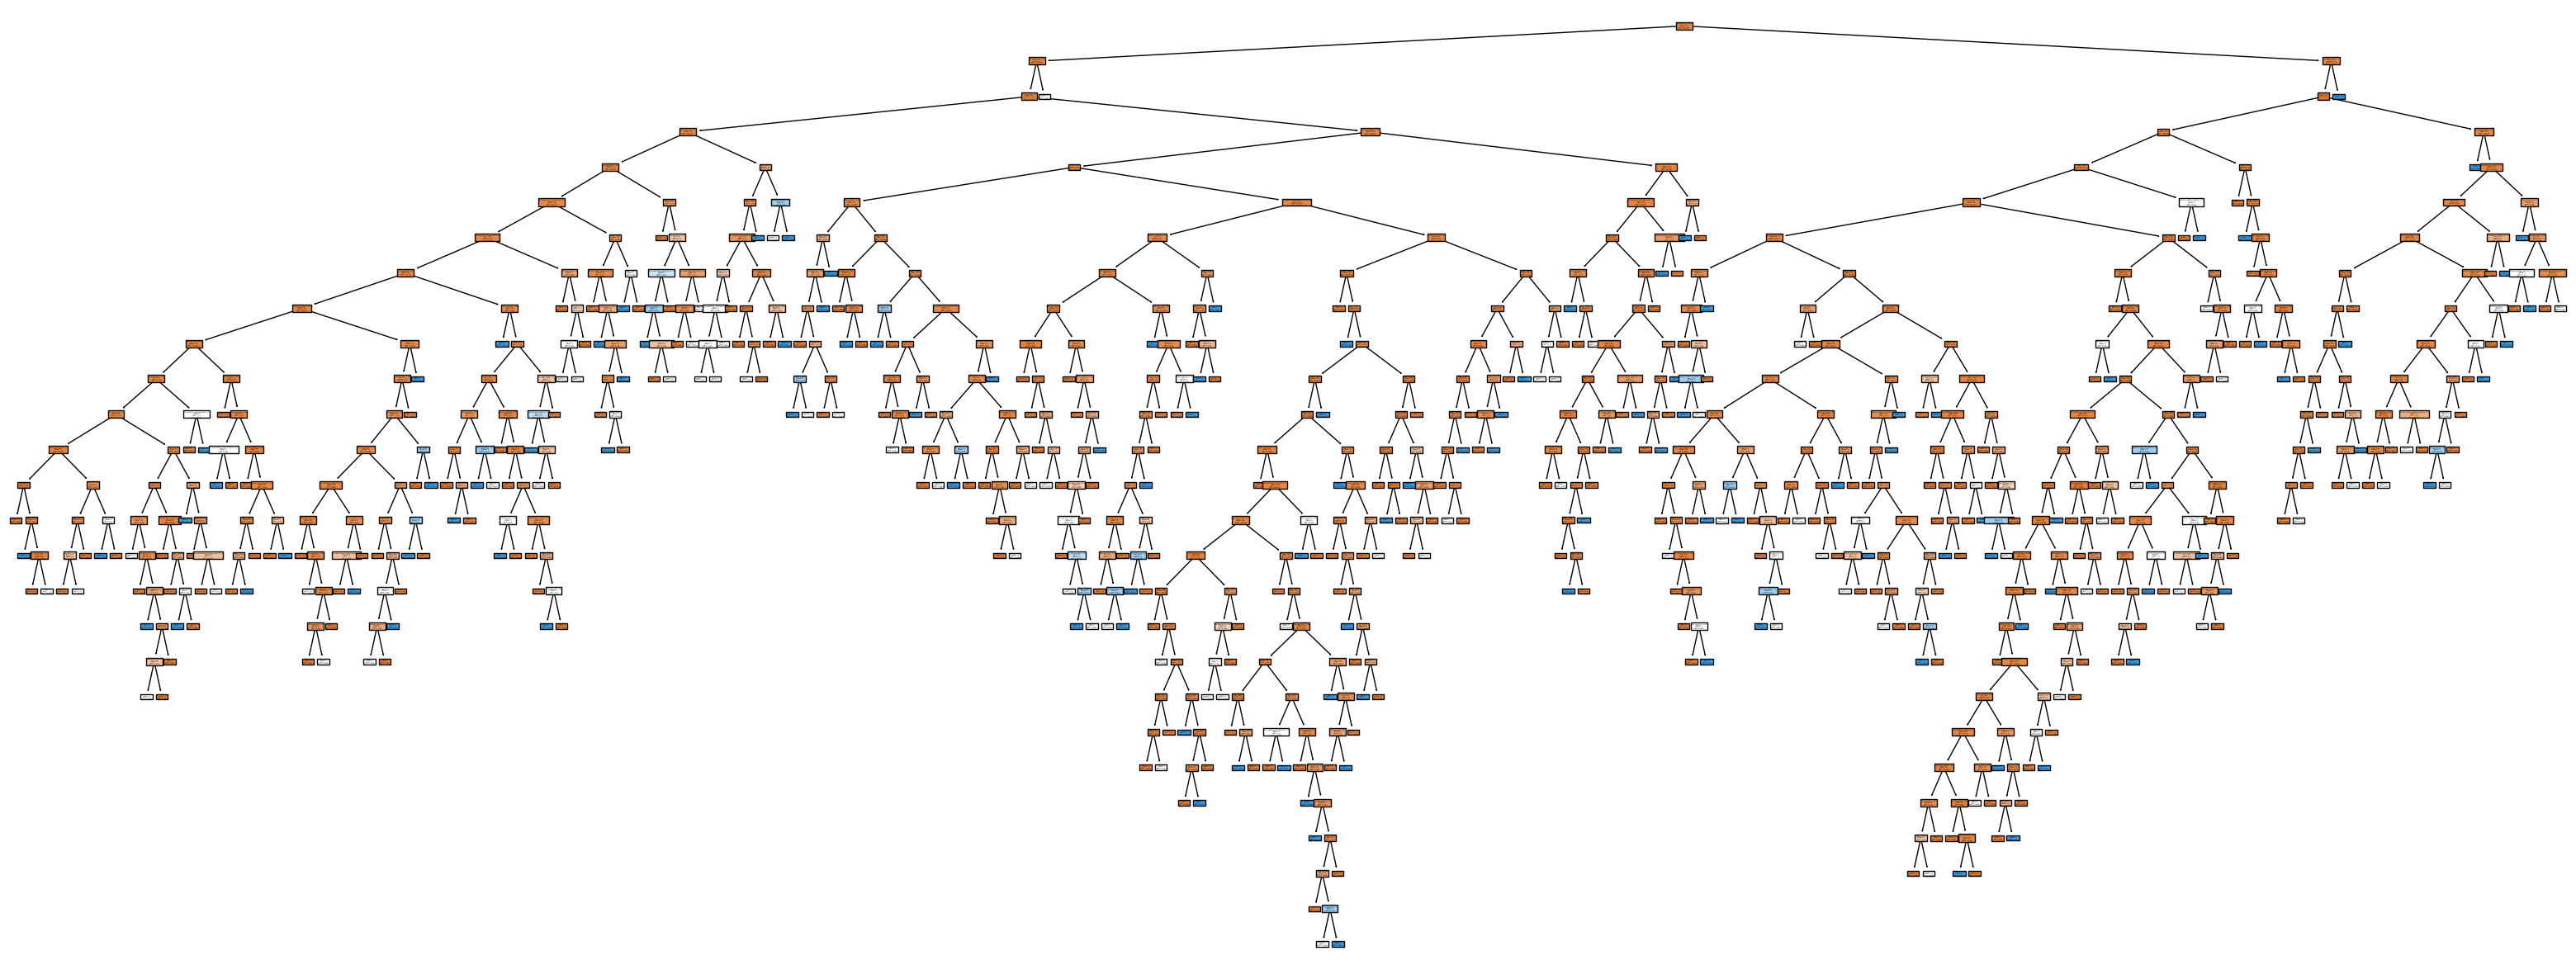

In [47]:
clf = DecisionTreeClassifier(random_state=100)
clf = clf.fit(X_train, y_train)
plt.figure(figsize=(40, 15))
plot_tree(clf,
          filled=True,
          class_names=['Aprovados', 'Reprovados'],
          feature_names=list(X.columns));

(<sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x1fea806ed50>,
 0.9852289512555391)

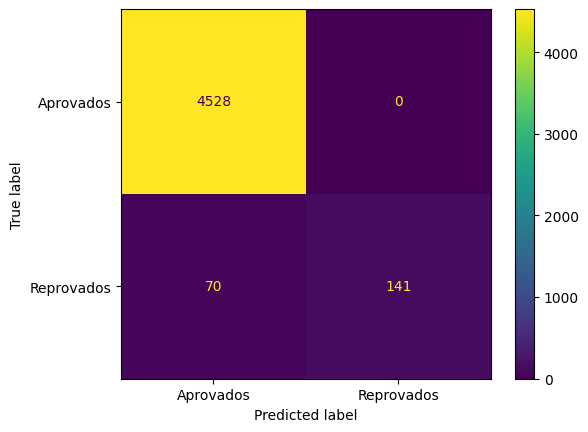

In [48]:
cm = confusion_matrix(y_train, clf.predict(X_train), labels=clf.classes_)
MatrizDeConfusao = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Aprovados', 'Reprovados'])

MatrizDeConfusao.plot(), accuracy_score(y_train, clf.predict(X_train))

#### 3) Vamos avaliar o modelo na base de testes

1. Classifique a base de teste de acordo com a árvore que você treinou no item 2.
2. Produza a visualização da matriz de confusão para a base de teste.
3. Calcule a acurácia da base de teste. Compare com a acurácia da base de treinamento.
4. Treine uma nova árvore com número mínimo de observações por folha de 5 e máximo de profundidade de 10. Use o random_state = 123. Avalie a matriz de classificação. Observe a distribuição da predição - qual a proporção de proponentes foram classificados como 'maus'?
5. Como ficaria a acurácia se você classificasse todos os contratos como 'bons'?

# Avaliando a Árvore e Refinando a Acurácia

A acurácia da base treino foi 0.9852289512555391 e a de teste foi 0.9172821270310192


(<sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x1feab30ecf0>,
 0.9172821270310192,
 None)

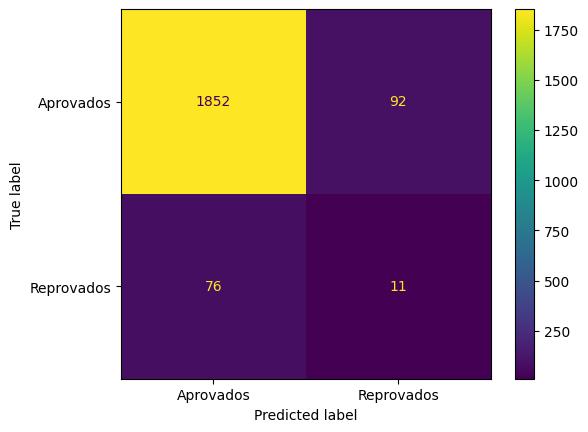

In [49]:
y_predict = clf.predict(X_test)
cm = confusion_matrix(y_test, y_predict, labels=clf.classes_)
MatrizDeConfusao = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Aprovados', 'Reprovados'])

MatrizDeConfusao.plot(), accuracy_score(y_test, y_predict), print(f'A acurácia da base treino foi {accuracy_score(y_train, clf.predict(X_train))} e a de teste foi {accuracy_score(y_test, y_predict)}')


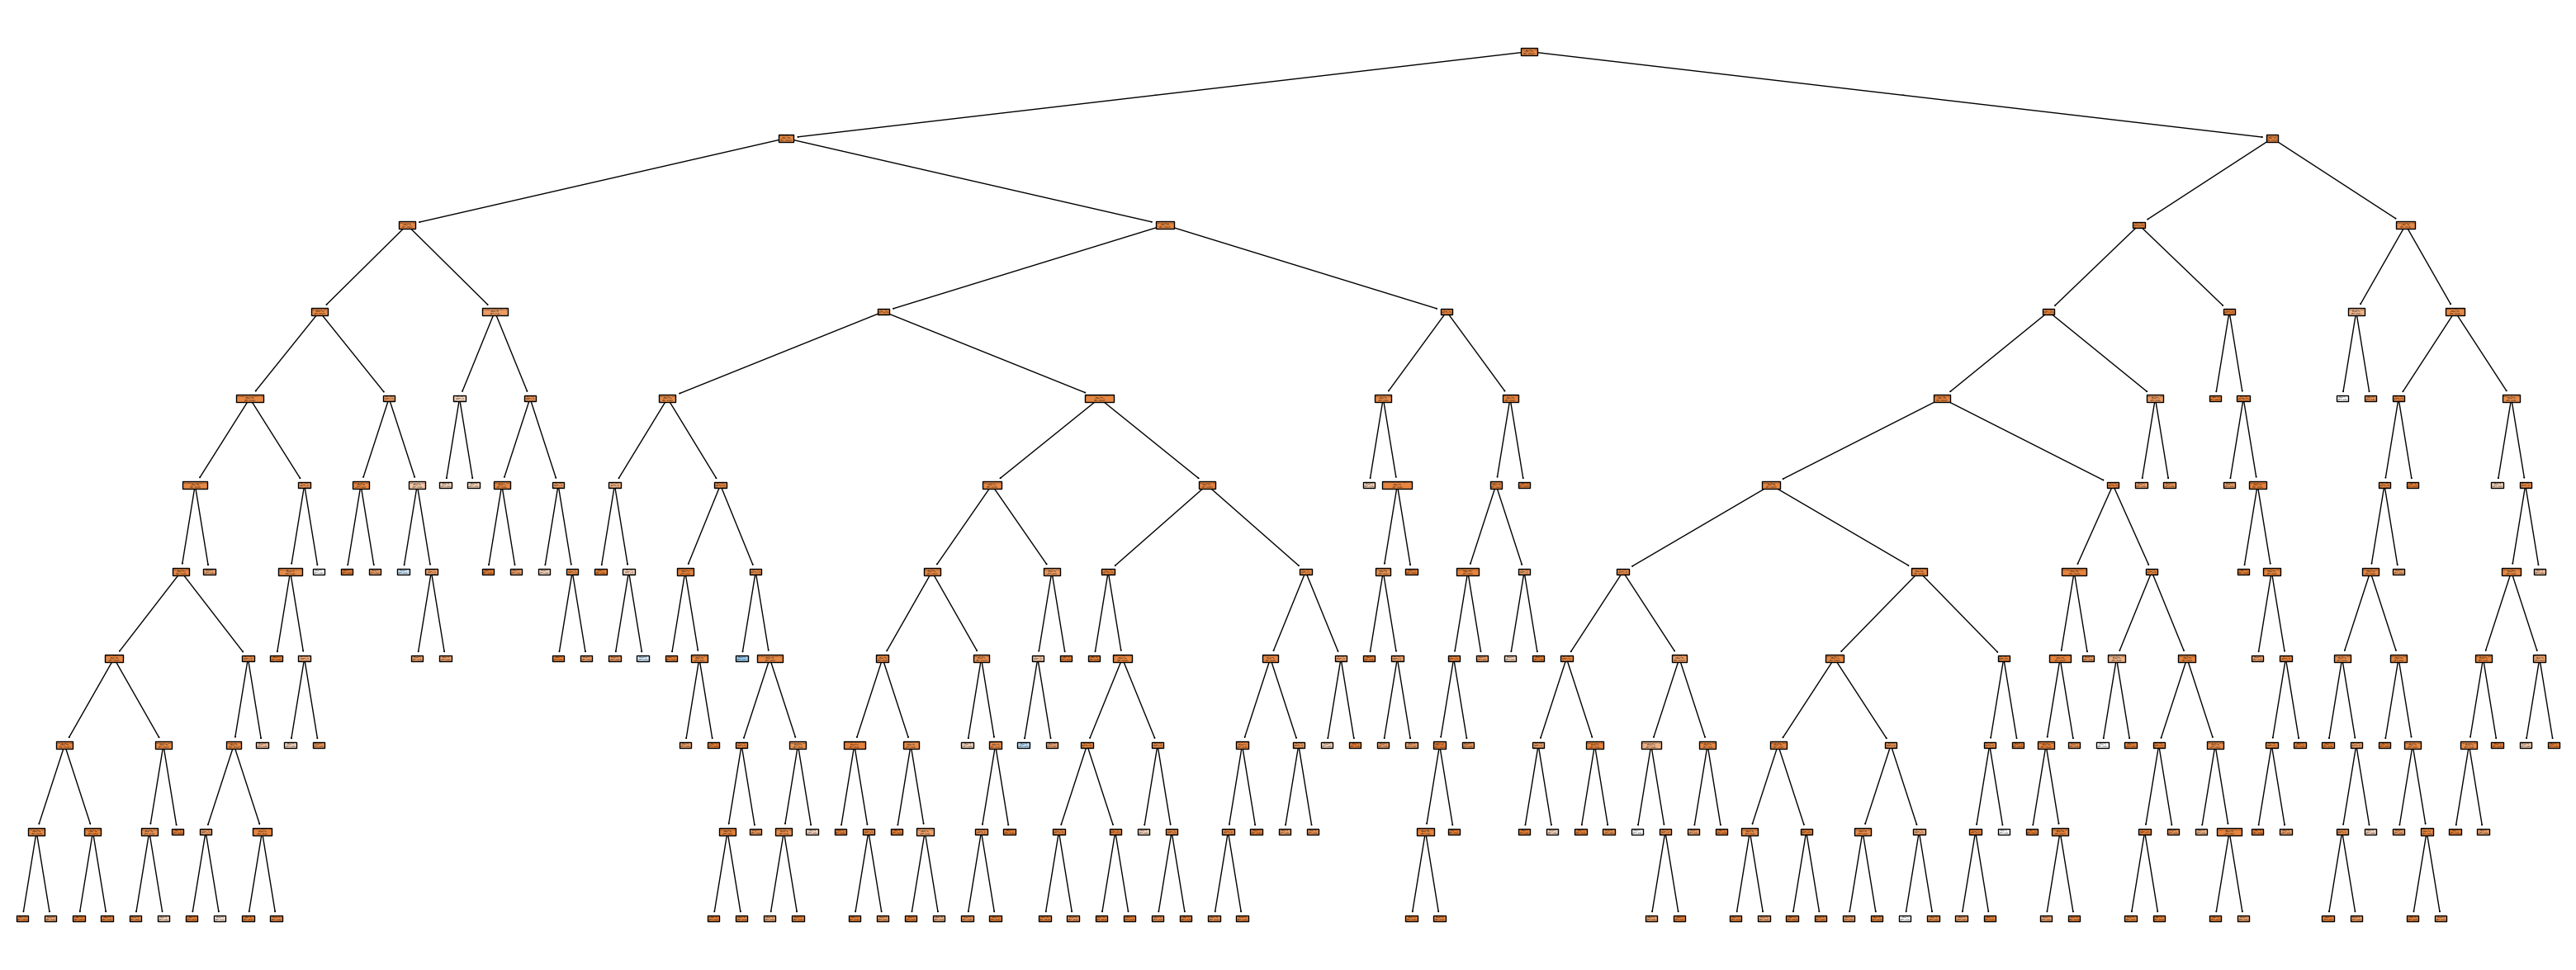

In [50]:
clf_next = DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=123)
clf_next = clf_next.fit(X_train, y_train)
plt.figure(figsize=(40, 15))
plot_tree(clf_next,
          filled=True,
          class_names=['Aprovados', 'Reprovados'],
          feature_names=list(X.columns));

(<sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x1feab4f4590>,
 0.9537173806006893)

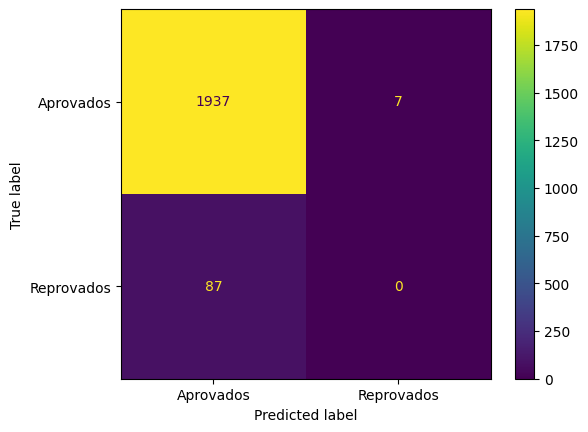

In [51]:
y_predict_next = clf_next.predict(X_test)
cm = confusion_matrix(y_test, y_predict_next, labels=clf.classes_)
MatrizDeConfusao = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Aprovados', 'Reprovados'])

MatrizDeConfusao.plot(), accuracy_score(y_test, y_predict_next) # A precisão aumenta e os maus são classificados em 0 nos acertos.

In [58]:
y_bons = y.copy()
y_bons[:] = 0
y_bons

0        0
1        0
3        0
4        0
6        0
        ..
16644    0
16645    0
16646    0
16647    0
16649    0
Name: mau, Length: 6770, dtype: int64

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y_bons, test_size=0.3, random_state=100)

In [60]:
clf_bons = DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=123)
clf_bons = clf_bons.fit(X_test,y_test)
predict = clf.predict(X_test)
accuracy_score(y_test, predict) # Haveria redução de acurácia caso todos fossem considerados 0.

0.9492860659773511